In [1]:
import os
import sys
sys.path.insert(0, "/hkfs/work/workspace/scratch/cc7738-automorphism/ANP4Link/")
import argparse
import csv
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
import torch
from torch import Tensor
from scipy.sparse.linalg import eigsh
from scipy.stats import qmc
from typing import Optional
from torch_geometric.datasets import Planetoid
from torch_geometric.nn import WLConv
from torch_geometric.typing import Adj
from torch_geometric.utils import (
    degree,
    is_sparse,
    scatter,
    sort_edge_index,
    to_edge_index,
    from_networkx,
    to_networkx
)
from collections import defaultdict
import matplotlib.pyplot as plt
from torch_geometric.datasets import Planetoid, Amazon
from torch_geometric.utils import train_test_split_edges, to_undirected
import random
from networkx import random_regular_graph
from syn_graph.graph_generation import GraphType 
from syn_graph.syn_random import RegularTilling
from collections import Counter
from syn_graph.syn_random import init_regular_tilling
from syn_graph.graph_generation import (generate_graph)
from syn_real.custom_wl import WLConvOptimized
from syn_real.mot import (run_wl_test_and_group_nodes,
                          compute_automorphism_metrics,
                          count_orbit_edges, plot_orbit_dist,
                          plot_orbit, plot_triangular_graph,
                          plot_graph_with_orbits)

/home/hk-project-test-p0021478/cc7738/anaconda3/envs/EAsF/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def plot_triangular_graph(G, orbits, custom_labels=None, figsize=(8, 6), cmap='Blues'):
    """
    Plots a triangular lattice graph with node coloring based on orbit labels.

    Parameters:
        G (nx.Graph): The triangular lattice graph to plot.
        orbits (list or dict): Orbit label for each node.
        custom_labels (dict, optional): Custom labels for nodes.
        figsize (tuple): Size of the figure.
        cmap (str): Matplotlib colormap name.
    """
    
    plt.figure(figsize=(6, 6))
    labels = {}
    for i, node in enumerate(G.nodes()):
        labels.update({node: orbits[i].item()})
    nx.draw(
        G,
        # node_color=orbits, 
        with_labels=True,
        labels=labels,
        node_size=1500,       # Increase node size (default is ~300–600)
        edgecolors='black',
        font_weight='bold',
        font_size=14          
    )

    plt.title("Graph Colored by Float Values", fontsize=16) 
    plt.axis('equal')
    plt.tight_layout()
    plt.show()
    plt.close()

In [3]:

def create_disjoint_graph(data):
    """
    Creates two disjoint copies of a real-world graph (e.g., Cora).
    Args:
        data (Data): PyG Data object representing the original graph.
    Returns:
        Data: PyG Data object representing the new merged graph.
    """
    num_nodes = data.num_nodes
    G = to_networkx(data, to_undirected=True)
    G2 = nx.relabel_nodes(G, lambda x: x + num_nodes)
    merged_graph = nx.compose(G, G2)
    merged_data = from_networkx(merged_graph)
    merged_data.edge_index = torch.cat([merged_data.edge_index, torch.tensor([num_nodes-1, num_nodes-1 + num_nodes]).unsqueeze(dim=1)], dim=1)
    if hasattr(data, 'x'):
        data.x = torch.ones((data.num_nodes, 16))
    merged_data.x = torch.cat([data.x, data.x], dim=0)
    
    return merged_data, merged_graph



In [ ]:
def semi_syn_graph(N, graph_type, pos=None):
    print(f"Processing graph of type {graph_type} with {N} nodes")
    if graph_type == RegularTilling.SQUARE_GRID:
        G, _, _, pos = init_regular_tilling(N, RegularTilling.SQUARE_GRID, seed=None)
    elif graph_type == 'GraphType.COMPLETE':
        graph_type = 'GraphType.COMPLETE'
        G = nx.complete_graph(N)
    else:
        G = generate_graph(N, graph_type, seed=0)
    
    # Process Graph with WL Test
    data = from_networkx(G)
    print(f"Graph type: {graph_type}, Number of nodes: {data.num_nodes}, Number of edges: {data.num_edges}")
    print(f"Number of nodes in the graph: {data.num_nodes}")
    mdata, mG = create_disjoint_graph(data)
    print(f"Merged Graph type: {graph_type}, Number of nodes: {mdata.num_nodes}, Number of edges: {mdata.num_edges}")
    print(mdata)

    # check the WL distribution
    node_groups, node_labels, orbits = run_wl_test_and_group_nodes(data.edge_index, num_nodes=data.num_nodes, num_iterations=100)
    custom_labels = {}
    for i, ov in zip(G.nodes(), orbits):
            custom_labels[i] = f"{ov}"
    plot_graph_with_orbits(G, None, orbits, custom_labels=custom_labels, figsize=(8, 6), cmap='tab20b')
    count_orbit_edges(G, node_labels)

    mnode_groups, mnode_labels, morbits = run_wl_test_and_group_nodes(mdata.edge_index, num_nodes=mdata.num_nodes, num_iterations=100)
    # metrics, num_nodes, group_sizes = compute_automorphism_metrics(node_groups, G.number_of_nodes())


    custom_labels = {}
    for i, ov in zip(mG.nodes(), morbits):
            custom_labels[i] = f"{ov}"
    plot_graph_with_orbits(mG, None, morbits, custom_labels=custom_labels, figsize=(8, 6), cmap='tab20b')
    count_orbit_edges(mG, mnode_labels)
    return 

Processing graph of type GraphType.BARABASI_ALBERT with 10 nodes
Graph type: GraphType.BARABASI_ALBERT, Number of nodes: 10, Number of edges: 32
Number of nodes in the graph: 10
Merged Graph type: GraphType.BARABASI_ALBERT, Number of nodes: 20, Number of edges: 65
Data(edge_index=[2, 65], num_nodes=20, x=[20, 16])


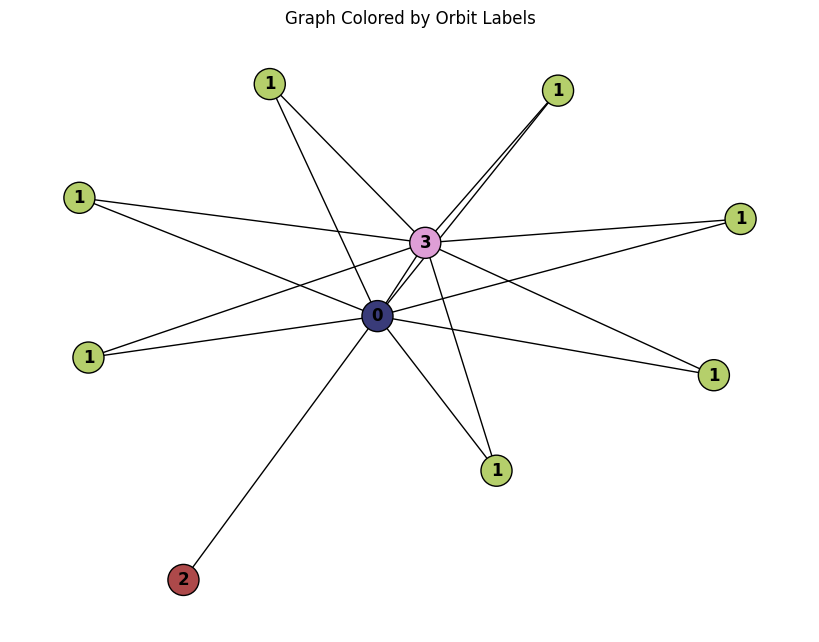

Intra-orbit edges: 0, Inter-orbit edges: 16


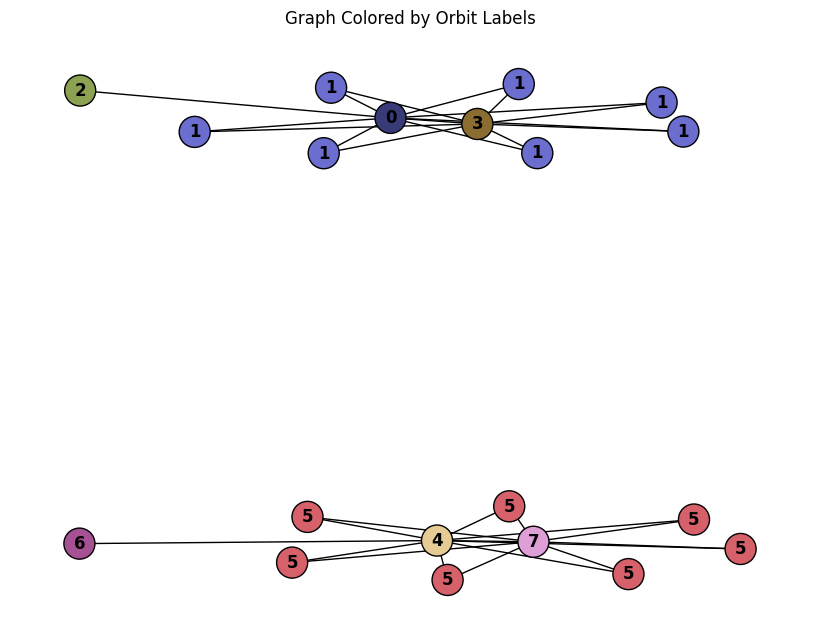

Intra-orbit edges: 0, Inter-orbit edges: 32


In [5]:
semi_syn_graph(10, GraphType.BARABASI_ALBERT)

Processing graph of type GraphType.BARABASI_ALBERT with 20 nodes
Graph type: GraphType.BARABASI_ALBERT, Number of nodes: 20, Number of edges: 102
Number of nodes in the graph: 20
Merged Graph type: GraphType.BARABASI_ALBERT, Number of nodes: 40, Number of edges: 205
Data(edge_index=[2, 205], num_nodes=40, x=[40, 16])


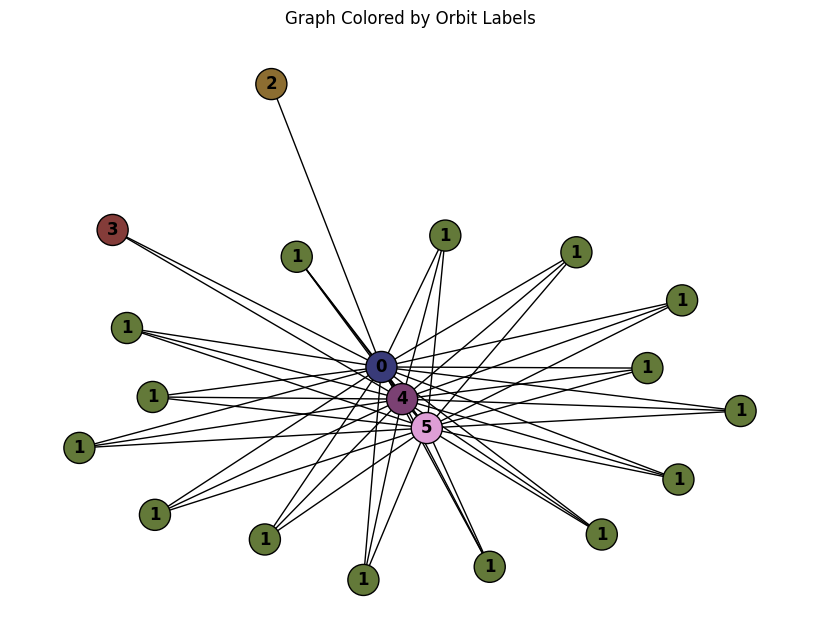

Intra-orbit edges: 0, Inter-orbit edges: 51


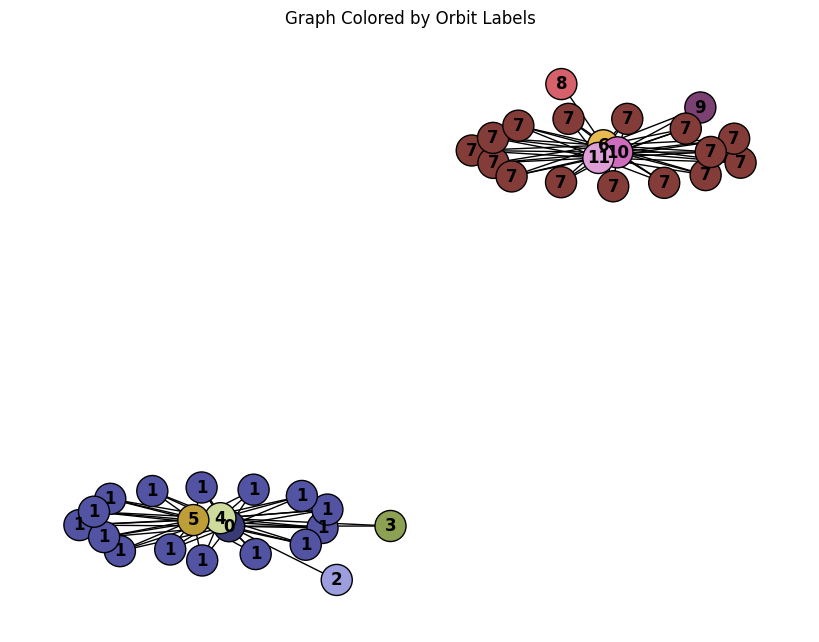

Intra-orbit edges: 0, Inter-orbit edges: 102


In [6]:
semi_syn_graph(20, GraphType.BARABASI_ALBERT)